# LightGBM Model - Return to Hospital

Gradient boosting model for rth_next_30d.

In [1]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import lightgbm as lgb
import optuna
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
import joblib
import warnings
import logging

warnings.filterwarnings("ignore")
logging.getLogger("lightgbm").setLevel(logging.ERROR)

In [2]:
def find_repo_root(start: Path) -> Path:
    candidates = [start] + list(start.parents)
    for path in candidates:
        dataset_path = path / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
        if dataset_path.exists():
            return path
        if (path / "src").exists() and (path / "outputs").exists():
            return path
    raise FileNotFoundError("Could not locate repo root with outputs/datavision_weekly_2023-08_2025-01.parquet")


def find_snapshot_col(df: pd.DataFrame) -> str:
    candidates = [
        "snapshot_date",
        "snapshot_dt",
        "snapshot",
        "reference_date",
        "as_of_date",
        "week_start",
    ]
    for col in candidates:
        if col in df.columns:
            return col
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ["snapshot", "reference", "as_of", "week", "date", "dt", "time"])]
    for col in date_cols:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            return col
    for col in date_cols:
        parsed = pd.to_datetime(df[col], errors="coerce")
        if parsed.notna().mean() >= 0.9:
            return col
    raise ValueError("No snapshot date column found.")


def ensure_labels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "fall_next_30d" not in df.columns and "label_fall_30d" in df.columns:
        df = df.rename(columns={"label_fall_30d": "fall_next_30d"})
    if "rth_next_30d" not in df.columns and "label_rth_30d" in df.columns:
        df = df.rename(columns={"label_rth_30d": "rth_next_30d"})
    missing = [c for c in ["fall_next_30d", "rth_next_30d"] if c not in df.columns]
    if missing:
        raise ValueError(f"Missing label columns: {missing}")
    return df


def temporal_split(df: pd.DataFrame, date_col: str) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.dropna(subset=[date_col])
    train_end = pd.Timestamp("2024-07-01")
    val_end = pd.Timestamp("2024-11-01")
    train = df[df[date_col] < train_end]
    val = df[(df[date_col] >= train_end) & (df[date_col] < val_end)]
    test = df[df[date_col] >= val_end]
    return train, val, test


def prepare_features(df: pd.DataFrame, label_col: str) -> tuple[pd.DataFrame, pd.Series]:
    id_cols = [c for c in ["resident_id", "facility_id", "patient_id", "person_id"] if c in df.columns]
    date_cols = [c for c in df.columns if any(k in c.lower() for k in ["date", "dt", "time", "snapshot", "as_of", "week", "reference"])]
    drop_cols = set(id_cols + date_cols + [label_col, "fall_next_30d", "rth_next_30d"])
    numeric_cols = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore").select_dtypes(include=["number"]).columns
    X = df[numeric_cols].copy()
    missing_rate = X.isna().mean()
    X = X.loc[:, missing_rate <= 0.95]
    constant_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
    X = X.drop(columns=constant_cols)
    days_cols = [c for c in X.columns if "days_since_last" in c]
    X.loc[:, days_cols] = X[days_cols].fillna(365)
    y = df[label_col].astype(int)
    return X, y


def recall_at_k(y_true: np.ndarray, y_score: np.ndarray, k: float = 0.10) -> float:
    n_top = max(1, int(len(y_true) * k))
    order = np.argsort(-y_score)
    top_true = y_true[order][:n_top]
    return float(top_true.sum() / max(1, y_true.sum()))

In [3]:
root = find_repo_root(Path.cwd())
dataset_path = root / "outputs" / "datavision_weekly_2023-08_2025-01.parquet"
df = pd.read_parquet(dataset_path)
df = ensure_labels(df)
date_col = find_snapshot_col(df)
train_df, val_df, test_df = temporal_split(df, date_col)
df.shape, train_df.shape, val_df.shape, test_df.shape

((64089, 204), (34772, 204), (16251, 204), (13066, 204))

In [ ]:
X_train, y_train = prepare_features(train_df, "rth_next_30d")
X_val, y_val = prepare_features(val_df, "rth_next_30d")
X_test, y_test = prepare_features(test_df, "rth_next_30d")

val_missing = sorted(set(X_train.columns) - set(X_val.columns))
val_extra = sorted(set(X_val.columns) - set(X_train.columns))
test_missing = sorted(set(X_train.columns) - set(X_test.columns))
test_extra = sorted(set(X_test.columns) - set(X_train.columns))

print(f"Val missing from train: {len(val_missing)}; extra in val: {len(val_extra)}")
print(f"Test missing from train: {len(test_missing)}; extra in test: {len(test_extra)}")
if val_missing or val_extra:
    print("Val drift sample:", (val_missing + val_extra)[:10])
if test_missing or test_extra:
    print("Test drift sample:", (test_missing + test_extra)[:10])

X_val_aligned = X_val.reindex(columns=X_train.columns)
X_test_aligned = X_test.reindex(columns=X_train.columns)

train_missing = X_train.isna().mean()
val_missing_rate = X_val_aligned.isna().mean()
test_missing_rate = X_test_aligned.isna().mean()

train_mean = X_train.mean()
val_mean = X_val_aligned.mean()
test_mean = X_test_aligned.mean()
train_std = X_train.std().replace(0, np.nan)
val_shift = (val_mean - train_mean).abs() / train_std
test_shift = (test_mean - train_mean).abs() / train_std
val_shift = val_shift.fillna(0.0)
test_shift = test_shift.fillna(0.0)

missing_thresh = 0.9
drift_thresh = 3.0
stable_cols = [
    c
    for c in X_train.columns
    if train_missing.get(c, 1.0) <= missing_thresh
    and val_missing_rate.get(c, 1.0) <= missing_thresh
    and val_shift.get(c, 0.0) <= drift_thresh
]
dropped_cols = [c for c in X_train.columns if c not in stable_cols]
print(f"Dropping unstable features: {len(dropped_cols)}")
if dropped_cols:
    print("Drop sample:", dropped_cols[:10])
test_only_drift = [
    c for c in X_train.columns
    if test_missing_rate.get(c, 1.0) > missing_thresh
    or test_shift.get(c, 0.0) > drift_thresh
]
if test_only_drift:
    print("Test-only drift (not filtered):", test_only_drift[:10])

top_features_path = root / "outputs" / "selected_features_top100_label_rth_30d.csv"
if top_features_path.exists():
    top_features = pd.read_csv(top_features_path)["feature"].dropna().astype(str).tolist()
    stable_cols = [c for c in stable_cols if c in top_features]
    print(f"Using top-100 rth features: {len(stable_cols)}")
else:
    print("Top-100 rth feature list not found; using stability filter only")

X_train = X_train[stable_cols]
X_val = X_val_aligned[stable_cols]
X_test = X_test_aligned[stable_cols]

pos_weight = (y_train == 0).sum() / max(1, (y_train == 1).sum())

def recall_at_10_metric(y_true: np.ndarray, y_pred: np.ndarray) -> tuple[str, float, bool]:
    return "recall_at_10", recall_at_k(y_true, y_pred, k=0.10), True

def get_scores(model: lgb.LGBMClassifier, X: pd.DataFrame) -> np.ndarray:
    preds = model.predict_proba(X, num_iteration=model.best_iteration_)
    return preds[:, 1]

optuna.logging.set_verbosity(optuna.logging.WARNING)
n_trials = 100

def optuna_objective(trial: optuna.Trial) -> float:
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "min_child_weight": trial.suggest_float("min_child_weight", 1e-3, 10.0, log=True),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.1),
        "max_depth": trial.suggest_categorical("max_depth", [-1, 4, 6, 8, 10, 12]),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-3, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-3, 10.0, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    }
    model = lgb.LGBMClassifier(
        n_estimators=1000,
        boosting_type="gbdt",
        objective="binary",
        subsample_freq=1,
        scale_pos_weight=pos_weight,
        verbosity=-1,
        random_state=42,
        **params,
    )
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_val, y_val)],
        eval_metric=recall_at_10_metric,
        callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=-1)],
    )
    y_score_val_raw = get_scores(model, X_val)
    return recall_at_k(y_val.values, y_score_val_raw, k=0.10)

def optuna_progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
    if trial.number % 10 == 0 or trial.value == study.best_value:
        print(
            f"  Trial {trial.number:>3d} | "
            f"recall@10={trial.value:.4f} | "
            f"best={study.best_value:.4f} | "
            f"params={trial.params}"
        )

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=15, n_warmup_steps=50),
)
print(f"Starting Optuna search: {n_trials} trials")
study.optimize(optuna_objective, n_trials=n_trials, callbacks=[optuna_progress_callback])
best_params = study.best_params
best_recall_at_10 = float(study.best_value)

print(f"\n{'='*60}")
print(f"Optuna complete — {len(study.trials)} trials")
print(f"Best recall@10%: {best_recall_at_10:.4f}")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"{'='*60}\n")

model = lgb.LGBMClassifier(
    n_estimators=1000,
    boosting_type="gbdt",
    objective="binary",
    subsample_freq=1,
    scale_pos_weight=pos_weight,
    verbosity=-1,
    random_state=42,
    **best_params,
 )
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric=recall_at_10_metric,
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(period=-1)],
 )

y_score_val = get_scores(model, X_val)
y_score_test = get_scores(model, X_test)

def threshold_at_k(y_score: np.ndarray, k: float = 0.10) -> float:
    n_top = max(1, int(len(y_score) * k))
    return float(np.sort(y_score)[-n_top])

best_threshold = threshold_at_k(y_score_val, k=0.10)

def top_k_metrics(y_true: np.ndarray, y_score: np.ndarray, k: float = 0.10) -> tuple[float, float]:
    if len(y_true) == 0:
        return 0.0, 0.0
    n_top = max(1, int(len(y_true) * k))
    order = np.argsort(-y_score)
    top_true = y_true[order][:n_top]
    positives = float(top_true.sum())
    recall_at_k = positives / max(1.0, float(y_true.sum()))
    precision_at_k = positives / float(n_top)
    return recall_at_k, precision_at_k

def evaluate_at_threshold(y_true: np.ndarray, y_score: np.ndarray, threshold: float) -> dict:
    y_pred = (y_score >= threshold).astype(int)
    metrics = {
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else None,
        "pr_auc": float(average_precision_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else None,
        "threshold": float(threshold),
        "predicted_positive_rate": float(y_pred.mean()),
    }
    recall_at_10pct, precision_at_10pct = top_k_metrics(y_true, y_score, k=0.10)
    metrics["recall_at_10pct"] = float(recall_at_10pct)
    metrics["precision_at_10pct"] = float(precision_at_10pct)
    return metrics

metrics_val = evaluate_at_threshold(y_val.values, y_score_val, best_threshold)
metrics_test = evaluate_at_threshold(y_test.values, y_score_test, best_threshold)

print(f"Threshold set for top-10% on val: {best_threshold:.4f}")
metrics_val, metrics_test

Val missing from train: 0; extra in val: 1
Test missing from train: 0; extra in test: 17
Val drift sample: ['therapy_tracks_days_since_last']
Test drift sample: ['adl_last', 'adl_mean_30d', 'adl_mean_90d', 'adl_responses_days_since_last', 'adl_slope_30d', 'adl_slope_90d', 'adl_std_30d', 'adl_std_90d', 'gg_last', 'gg_mean_30d']
Dropping unstable features: 1
Drop sample: ['gg_mobility_latest_sum']
Test-only drift (not filtered): ['adl_responses_count_180d', 'gg_mobility_latest_sum']
Using top-100 rth features: 100
Starting Optuna search: 150 trials
  Trial   0 | recall@10=0.3285 | best=0.3285 | params={'num_leaves': 125, 'learning_rate': 0.0862735828664018, 'min_child_samples': 75, 'min_child_weight': 0.24810409748678114, 'min_split_gain': 0.015601864044243652, 'max_depth': 6, 'lambda_l1': 7.5794799533480015, 'lambda_l2': 2.136832907235876, 'feature_fraction': 0.5274034664069657, 'subsample': 0.5909124836035503}
  Trial   1 | recall@10=0.3388 | best=0.3388 | params={'num_leaves': 71, 'le

In [ ]:
from datetime import datetime

reports_dir = root / "reports"
plots_dir = reports_dir / "plots"
models_dir = root / "models"
reports_dir.mkdir(exist_ok=True)
plots_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(exist_ok=True)

run_id = datetime.utcnow().strftime("%Y%m%dT%H%M%SZ")
metrics_rows = [
    {"run_id": run_id, "model": "lightgbm", "target": "rth_next_30d", "split": "val", **metrics_val},
    {"run_id": run_id, "model": "lightgbm", "target": "rth_next_30d", "split": "test", **metrics_test},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_path = reports_dir / "model_metrics.csv"
if metrics_path.exists():
    existing = pd.read_csv(metrics_path)
    metrics_df = pd.concat([existing, metrics_df], ignore_index=True)
metrics_df.to_csv(metrics_path, index=False)

joblib.dump(model, models_dir / "rth_lgb_model.pkl")

importance = pd.DataFrame(
    {
        "model": "lightgbm",
        "target": "rth_next_30d",
        "feature": X_train.columns,
        "importance": model.booster_.feature_importance(importance_type="gain"),
    }
).sort_values("importance", ascending=False).head(50)
feature_path = reports_dir / "feature_importance_lightgbm_rth.csv"
importance.to_csv(feature_path, index=False)

metrics_df.tail(20)

,run_id,model,target,split,precision,recall,f1,roc_auc,pr_auc,predicted_positive_rate,recall_at_10pct,precision_at_10pct,threshold
42,20260309T004241Z,lightgbm,rth_next_30d,val,0.114462,0.381930,0.176136,0.772865,0.180667,0.099994,0.381930,0.114462,0.080481
43,20260309T004241Z,lightgbm,rth_next_30d,test,0.097169,0.368116,0.153753,0.770839,0.162877,0.100031,0.368116,0.097243,0.080481
44,20260309T023003Z,lightgbm,rth_next_30d,val,0.029967,1.000000,0.058191,0.500000,0.029967,1.000000,0.080082,0.024000,0.000000
45,20260309T023003Z,lightgbm,rth_next_30d,test,0.026404,1.000000,0.051450,0.500000,0.026404,1.000000,0.072464,0.019142,0.000000
46,20260309T024217Z,lightgbm,rth_next_30d,val,0.029967,1.000000,0.058191,0.500000,0.029967,1.000000,0.080082,0.024000,0.500000
47,20260309T024217Z,lightgbm,rth_next_30d,test,0.026404,1.000000,0.051450,0.500000,0.026404,1.000000,0.072464,0.019142,0.500000
48,20260309T025832Z,lightgbm,rth_next_30d,val,0.141538,0.472279,0.217803,0.808828,0.165266,0.099994,0.472279,0.141538,0.043868
49,20260309T025832Z,lightgbm,rth_next_30d,test,0.122214,0.460870,0.193196,0.799341,0.178261,0.099571,0.463768,0.122511,0.043868
50,20260309T032356Z,lightgbm,fall_next_30d,val,0.347077,0.423106,0.381339,0.793643,0.333146,0.099994,0.423106,0.347077,0.290069
51,20260309T032356Z,lightgbm,fall_next_30d,test,0.282958,0.362140,0.317690,0.758613,0.260844,0.095209,0.376543,0.280245,0.290069


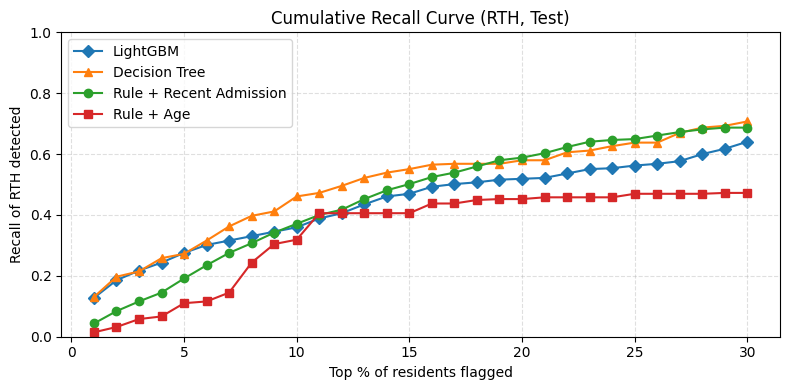

(PosixPath('/Users/marcelo.florencio/workspace/personal/tricura-incident-risk/reports/lightgbm_cumulative_recall_points_rth.csv'),
 PosixPath('/Users/marcelo.florencio/workspace/personal/tricura-incident-risk/reports/cumulative_recall_comparison.csv'),
               model         target  percent_flagged    recall
 0  rule_recent_fall  fall_next_30d                1  0.053498
 1  rule_recent_fall  fall_next_30d                2  0.101852
 2  rule_recent_fall  fall_next_30d                3  0.151235
 3  rule_recent_fall  fall_next_30d                4  0.191358
 4  rule_recent_fall  fall_next_30d                5  0.231481
 5  rule_recent_fall  fall_next_30d                6  0.267490
 6  rule_recent_fall  fall_next_30d                7  0.304527
 7  rule_recent_fall  fall_next_30d                8  0.337449)

In [ ]:
def recall_curve(y_true: np.ndarray, y_score: np.ndarray, max_pct: int = 30) -> tuple[np.ndarray, np.ndarray]:
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    total_pos = max(1.0, float(y_sorted.sum()))
    recalls = []
    percents = np.arange(1, max_pct + 1)
    for pct in percents:
        n_top = max(1, int(len(y_sorted) * (pct / 100.0)))
        recalls.append(float(y_sorted[:n_top].sum()) / total_pos)
    return percents, np.array(recalls)

percents, recalls_lgb = recall_curve(y_test.values, y_score_test, max_pct=30)

rule_points_path = reports_dir / "rule_cumulative_recall_points.csv"
tree_points_path = reports_dir / "decision_tree_cumulative_recall_points.csv"
rule_points = pd.read_csv(rule_points_path)
tree_points = pd.read_csv(tree_points_path)

rth_rule_recent = rule_points[(rule_points["target"] == "rth_next_30d") & (rule_points["tiebreaker"] == "recent_admission")].sort_values("percent_flagged")
rth_rule_age = rule_points[(rule_points["target"] == "rth_next_30d") & (rule_points["tiebreaker"] == "age")].sort_values("percent_flagged")
rth_tree = tree_points[tree_points["target"] == "rth_next_30d"].sort_values("percent_flagged")

plt.figure(figsize=(8, 4))
plt.plot(percents, recalls_lgb, marker="D", linewidth=1.5, label="LightGBM")
plt.plot(rth_tree["percent_flagged"], rth_tree["recall"], marker="^", linewidth=1.5, label="Decision Tree")
plt.plot(rth_rule_recent["percent_flagged"], rth_rule_recent["recall"], marker="o", linewidth=1.5, label="Rule + Recent Admission")
plt.plot(rth_rule_age["percent_flagged"], rth_rule_age["recall"], marker="s", linewidth=1.5, label="Rule + Age")
plt.xlabel("Top % of residents flagged")
plt.ylabel("Recall of RTH detected")
plt.title("Cumulative Recall Curve (RTH, Test)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.ylim(0, 1.0)
plt.legend()
plt.tight_layout()
plt.show()

lgb_points = pd.DataFrame({
    "model": "lightgbm",
    "target": "rth_next_30d",
    "percent_flagged": percents.astype(int),
    "recall": recalls_lgb.astype(float),
})
lgb_points_path = reports_dir / "lightgbm_cumulative_recall_points_rth.csv"
lgb_points.to_csv(lgb_points_path, index=False)

compare_df = pd.concat([
    rth_rule_recent.assign(model="rule_recent_admission"),
    rth_rule_age.assign(model="rule_age"),
    rth_tree.assign(model="decision_tree"),
    lgb_points.assign(model="lightgbm"),
]).loc[:, ["model", "target", "percent_flagged", "recall"]]
compare_path = reports_dir / "cumulative_recall_comparison.csv"
if compare_path.exists():
    existing = pd.read_csv(compare_path)
    existing = existing[existing["target"] != "rth_next_30d"]
    compare_df = pd.concat([existing, compare_df], ignore_index=True)
compare_df.to_csv(compare_path, index=False)

lgb_points_path, compare_path, compare_df.head(8)

In [ ]:
# Compare feature overlap: Decision Tree vs LightGBM (RTH)
tree_feature_path = root / "reports" / "feature_importance_decision_tree.csv"
if not tree_feature_path.exists():
    print("Decision tree feature importance file not found:", tree_feature_path)
else:
    tree_df = pd.read_csv(tree_feature_path)
    tree_df = tree_df[tree_df["target"] == "rth_next_30d"]
    tree_df = tree_df.sort_values("importance", ascending=False)
    tree_features = tree_df["feature"].dropna().astype(str).tolist()

    lgbm_features = list(X_train.columns)
    lgbm_set = set(lgbm_features)
    tree_set = set(tree_features)
    overlap = sorted(lgbm_set & tree_set)
    lgbm_only = sorted(lgbm_set - tree_set)
    tree_only = sorted(tree_set - lgbm_set)

    print(f"LGBM features: {len(lgbm_set)}")
    print(f"Tree features: {len(tree_set)}")
    print(f"Overlap: {len(overlap)}")

    tree_only_ranked = tree_df[tree_df["feature"].isin(tree_only)]["feature"].head(15).tolist()
    if "importance" in locals():
        lgbm_importance = importance.sort_values("importance", ascending=False)
        lgbm_only_ranked = lgbm_importance[lgbm_importance["feature"].isin(lgbm_only)]["feature"].head(15).tolist()
    else:
        lgbm_only_ranked = lgbm_only[:15]
    print("Tree-only top features:", tree_only_ranked)
    print("LGBM-only top features:", lgbm_only_ranked)
    print("Overlap sample:", overlap[:15])

LGBM features: 100
Tree features: 69
Overlap: 69
Tree-only top features: []
LGBM-only top features: ['vitals_weight_std_90d', 'vitals_weight_mean_90d', 'vitals_pain_level_mean_30d', 'vitals_pulse_mean_90d', 'vitals_pulse_mean_30d', 'vitals_o2_sats_mean_30d', 'vitals_pain_level_std_30d', 'vitals_pulse_std_90d', 'vitals_bp_systolic_mean_30d', 'vitals_weight_last', 'vitals_bp_systolic_min_90d', 'vitals_pulse_min_90d', 'vitals_bp_systolic_max_90d', 'vitals_bp_systolic_max_30d', 'vitals_respiration_mean_30d']
Overlap sample: ['age', 'care_plans_count_total', 'care_plans_days_since_last', 'comorb_dementia', 'comorb_depression', 'comorb_diabetes', 'comorbidity_count', 'days_since_admission', 'diagnoses_count_180d', 'diagnoses_count_90d', 'diagnoses_days_since_last', 'diagnosis_high_risk_flag', 'facility_rth_90d', 'facility_rth_rate_90d', 'hospital_admissions_count_180d']


 99%|===================| 1985/2000 [00:50<00:00]        

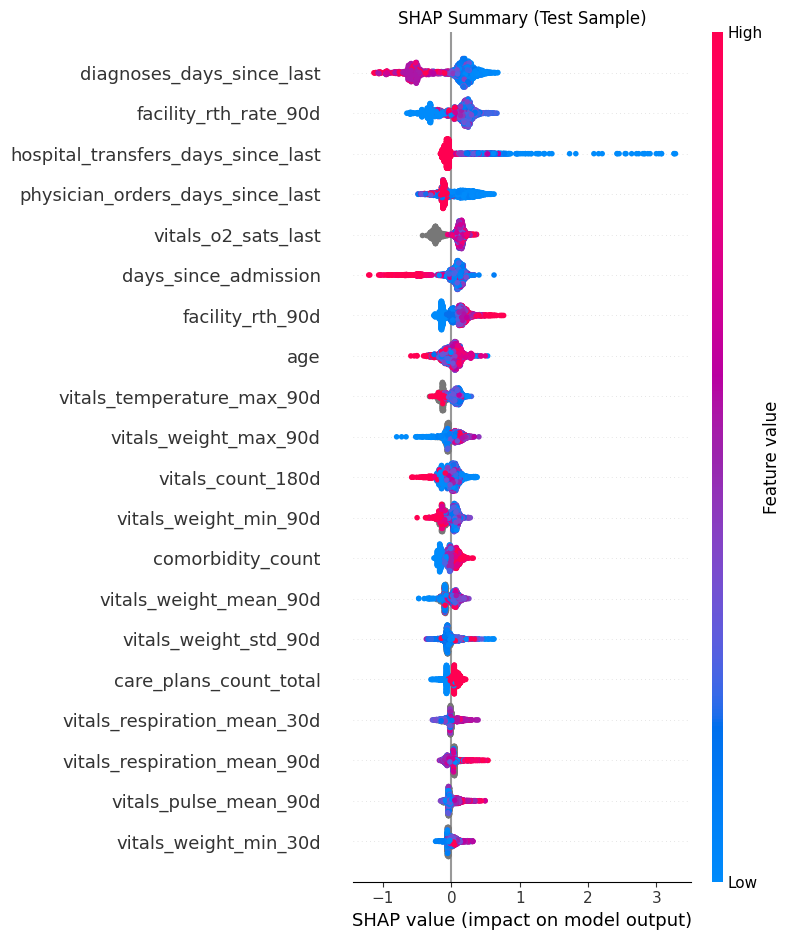

,feature,mean_abs_shap
0,diagnoses_days_since_last,0.338838
1,facility_rth_rate_90d,0.225394
2,hospital_transfers_days_since_last,0.188164
3,physician_orders_days_since_last,0.179047
4,vitals_o2_sats_last,0.163671
5,days_since_admission,0.143966
6,facility_rth_90d,0.142391
7,age,0.100116
8,vitals_temperature_max_90d,0.098539
9,vitals_weight_max_90d,0.097206


In [ ]:
import shap

sample_size = min(2000, len(X_test))
X_sample = X_test.sample(sample_size, random_state=42) if len(X_test) > 0 else X_test
background_size = min(200, len(X_train))
background = X_train.sample(background_size, random_state=42) if len(X_train) > 0 else X_train

explainer = shap.TreeExplainer(model, data=background, feature_perturbation="interventional")
shap_values = explainer.shap_values(X_sample, check_additivity=False)

if isinstance(shap_values, list):
    shap_values = shap_values[1] if len(shap_values) > 1 else shap_values[0]

shap.summary_plot(shap_values, X_sample, show=False)
plt.title("SHAP Summary (Test Sample)")
plt.tight_layout()
plt.show()

mean_abs = np.abs(shap_values).mean(axis=0)
top_idx = np.argsort(-mean_abs)[:10]
shap_top = pd.DataFrame({
    "feature": X_sample.columns[top_idx],
    "mean_abs_shap": mean_abs[top_idx],
})
shap_top

## SHAP Insights (RTH Model)

- The SHAP summary plot highlights which features most consistently push return-to-hospital risk up or down across the test sample.
- Features with large positive SHAP values increase predicted RTH risk; large negative values are protective signals.
- Note: SHAP values are in logit space (raw model output), not probability units. Directionality is correct since sigmoid is monotonic, but magnitudes cannot be interpreted as probability changes.
- Compare the top SHAP drivers with domain expectations (recent admissions, admissions history, comorbidity burden, vitals) to spot data issues or leakage.
- If the top drivers look unstable across time splits, revisit feature drift, missingness, or scaling choices.